# DDPM 噪声强度对比分析

本notebook用于比较扩散模型中调制噪声强度与直接叠加噪声强度的差异。

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 参数设置

使用DDPM的标准参数：
- T = 1000：总时间步数
- beta_min = 0.0001：最小噪声系数
- beta_max = 0.02：最大噪声系数

In [10]:
# 参数设置(DDPM标准参数)
T = 1000
beta_min = 0.0001
beta_max = 0.02

# 生成时间步
t = np.arange(1, T+1)

print(f"总时间步数: {T}")
print(f"Beta范围: {beta_min} 到 {beta_max}")

总时间步数: 1000
Beta范围: 0.0001 到 0.02


## 计算噪声强度

### 1. 扩散模型的调制噪声强度
- 使用线性调度的 beta_t
- 计算 alpha_t = 1 - beta_t
- 计算累积乘积 alpha_bar_t
- 最终噪声强度为 sqrt(1 - alpha_bar_t)

### 2. 无调制直接叠加噪声强度
- 假设每次叠加与 beta_t 同强度的噪声
- 总强度为各步噪声标准差的平方和开根号

In [11]:
# 1. 计算扩散模型的噪声系数(调制后的强度)
# 线性调度的beta_t
beta_linear = beta_min + (beta_max - beta_min) * (t - 1) / (T - 1)
# alpha_t = 1 - beta_t
alpha_t = 1 - beta_linear
# 累积乘积alpha_bar_t = product(alpha_s for s=1 to t)
alpha_bar_t = np.cumprod(alpha_t)
# 调制后的噪声强度(标准差)：sqrt(1 - alpha_bar_t)
modulated_strength = np.sqrt(1 - alpha_bar_t)

# 2. 计算无调制直接叠加噪声的强度(对比用)
# 假设每次叠加与beta_t同强度的噪声(标准差为sqrt(beta_t))
# 总强度为各步噪声标准差的平方和开根号(独立噪声叠加)
unmodulated_strength = np.sqrt(np.cumsum(beta_linear))

print(f"调制噪声强度范围: {modulated_strength.min():.4f} 到 {modulated_strength.max():.4f}")
print(f"无调制噪声强度范围: {unmodulated_strength.min():.4f} 到 {unmodulated_strength.max():.4f}")

调制噪声强度范围: 0.0100 到 1.0000
无调制噪声强度范围: 0.0100 到 3.1702


## 可视化对比

绘制两种噪声强度随时间步的变化曲线, 并进行对比。

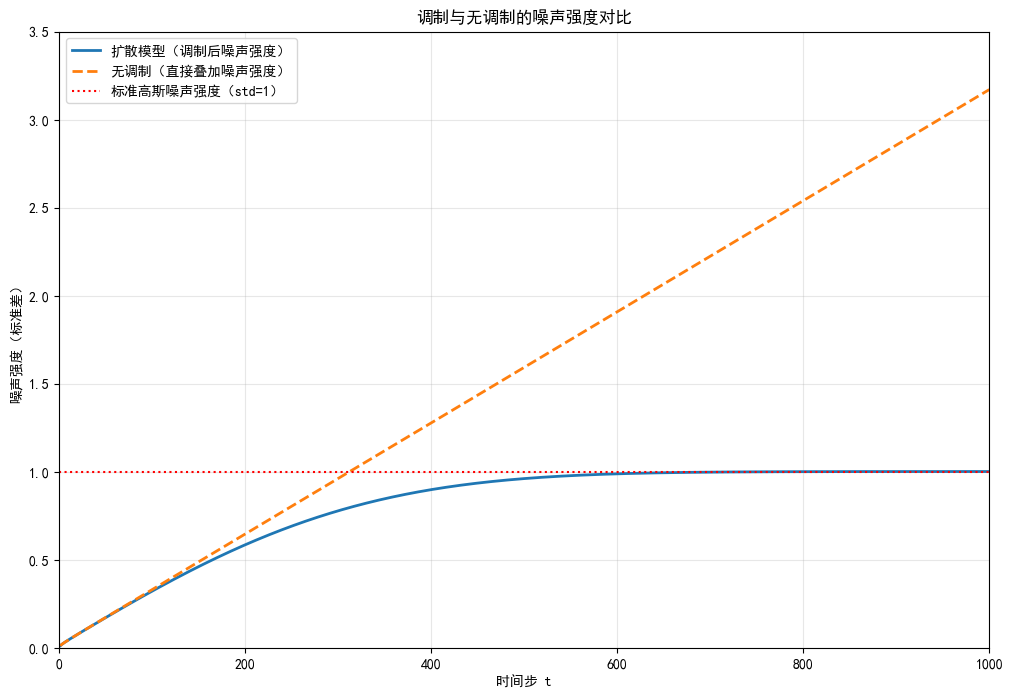

In [12]:
# 3. 绘制对比曲线
plt.figure(figsize=(12, 8))
plt.plot(t, modulated_strength, label='扩散模型(调制后噪声强度)', linewidth=2)
plt.plot(t, unmodulated_strength, label='无调制(直接叠加噪声强度)', linestyle='--', linewidth=2)
plt.axhline(y=1.0, color='r', linestyle=':', label='标准高斯噪声强度(std=1)')

plt.xlabel('时间步 t')
plt.ylabel('噪声强度(标准差)')
plt.title('调制与无调制的噪声强度对比')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, T)
plt.ylim(0, 3.5)  # 限制y轴范围以突出差异
plt.show()

## 结果分析

从图中可以看出：
1. **调制噪声强度**(蓝色实线)：扩散模型中通过调制方式添加的噪声, 强度增长相对缓慢, 最终趋近于1(标准高斯分布)
2. **无调制噪声强度**(橙色虚线)：直接叠加的噪声强度增长更快, 最终会超过1
3. 这种差异解释了为什么扩散模型能够有效地控制噪声添加过程, 从而实现高质量的去噪和生成效果